In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración visual para que los gráficos salgan mas claros en el notebook
plt.style.use('ggplot')
print("¡Librerías cargadas correctamente para el análisis exploratorio!")


¡Librerías cargadas correctamente para el análisis exploratorio!


In [2]:
# Cargamos el archivo CSV 
ruta_archivo = "../data/bronze/contratos_fiscalia_raw.csv"

df = pd.read_csv(ruta_archivo)

# Mostramos las primeras 5 filas para conocer las columnas
print("Vista previa de los datos crudos:")
df.head()

Vista previa de los datos crudos:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,...,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_de_respuesta,fecha_de_publicacion_fase_2,fecha_de_apertura_efectiva,fecha_adjudicacion
0,DEPARTAMENTO ADMINISTRATIVO NACIONAL DE ESTADI...,899999027,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.2577563,EDP-545-2022,700474109,CO1.BDOS.2503732,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700474109,Presentación de oferta,NaN,NaN,NaN,NaN,NaN
1,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,Territorial,Centralizada,CO1.REQ.2085169,CD-55-2021-3516,702442096,CO1.BDOS.2027130,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,702442096,Presentación de oferta,NaN,NaN,NaN,NaN,NaN
2,COLEGIO GABRIEL BETANCOURT MEJIA I.E.D,900143276,Distrito Capital de Bogotá,No Definido,Territorial,Centralizada,CO1.REQ.7128715,RE-CGBM-049-2024,703916536,CO1.BDOS.6995772,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703916536,Presentación de oferta,2024-11-12T00:00:00.000,2024-11-13T00:00:00.000,NaN,NaN,NaN
3,INVIAS,800215807,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.9845111,CD-CPS-0720-2026,700676059,CO1.BDOS.9677536,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700676059,Presentación de oferta,NaN,NaN,NaN,NaN,NaN
4,MUNICIPIO DE SAN MIGUEL PUTUMAYO,800252922,Putumayo,San Miguel,Territorial,Descentralizada,CO1.REQ.8273274,PS-147-2025,712452853,CO1.BDOS.8128286,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,712452853,Presentación de oferta,NaN,NaN,NaN,NaN,NaN


In [3]:
# Revisamos cuántas filas y columnas tiene nuestro dataset
filas, columnas = df.shape

print(f" Dimensiones del dataset:")
print(f"   - Total de filas (registros): {filas}")
print(f"   - Total de columnas (variables): {columnas}")

 Dimensiones del dataset:
   - Total de filas (registros): 100
   - Total de columnas (variables): 56


In [4]:
# Verificamos los nombres de todas las columnas y qué tipo de dato tienen
print("Listado de columnas y tipos de datos:")
df.info()

Listado de columnas y tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   entidad                         100 non-null    str  
 1   nit_entidad                     100 non-null    int64
 2   departamento_entidad            100 non-null    str  
 3   ciudad_entidad                  100 non-null    str  
 4   ordenentidad                    100 non-null    str  
 5   codigo_pci                      100 non-null    str  
 6   id_del_proceso                  100 non-null    str  
 7   referencia_del_proceso          100 non-null    str  
 8   ppi                             100 non-null    int64
 9   id_del_portafolio               100 non-null    str  
 10  nombre_del_procedimiento        100 non-null    str  
 11  descripci_n_del_procedimiento   100 non-null    str  
 12  fase                            100 no

In [5]:
# Detectar cuántos datos vacíos (nulos) tiene cada columna
nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

# Unimos todo en un pequeño DataFrame resumen para verlo ordenado
resumen_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos
})

# Filtramos solo las columnas que tienen algún valor nulo para no saturar la pantalla
resumen_nulos_filtrado = resumen_nulos[resumen_nulos['Cantidad de Nulos'] > 0]

print(" Resumen de valores nulos encontrados en los datos crudos:")
display(resumen_nulos_filtrado)

 Resumen de valores nulos encontrados en los datos crudos:


,Cantidad de Nulos,Porcentaje (%)
fecha_de_publicacion_fase_3,4,4.0
fecha_de_recepcion_de,80,80.0
fecha_de_apertura_de_respuesta,83,83.0
fecha_de_publicacion_fase_2,96,96.0
fecha_de_apertura_efectiva,86,86.0
fecha_adjudicacion,94,94.0


In [6]:
# Estadísticas descriptivas de las columnas numéricas o de conteo
df.describe(include='all')

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,...,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_de_respuesta,fecha_de_publicacion_fase_2,fecha_de_apertura_efectiva,fecha_adjudicacion
count,100,1.000000e+02,100,100,100,100,100,100,1.000000e+02,100,...,100,100,100,1.000000e+02,100,20,17,4,14,6
unique,88,NaN,23,41,2,2,97,97,NaN,97,...,1,8,97,NaN,4,17,14,4,14,6
top,ALCALDIA MUNICIPIO DE RICAURTE,NaN,Distrito Capital de Bogotá,No Definido,Territorial,Centralizada,CO1.REQ.3469058,MC 043-2022,NaN,CO1.BDOS.3379112,...,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,NaN,Presentación de oferta,2022-10-13T00:00:00.000,2022-10-13T00:00:00.000,2019-04-29T00:00:00.000,2019-06-18T00:00:00.000,2022-07-08T00:00:00.000
freq,4,NaN,31,25,67,79,4,4,NaN,4,...,100,93,4,NaN,84,4,4,1,1,1
mean,NaN,1.557664e+09,NaN,NaN,NaN,NaN,NaN,NaN,7.043056e+08,NaN,...,NaN,NaN,NaN,7.043056e+08,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.216835e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.626327e+06,NaN,...,NaN,NaN,NaN,4.626327e+06,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.000790e+08,NaN,NaN,NaN,NaN,NaN,NaN,7.000880e+08,NaN,...,NaN,NaN,NaN,7.000880e+08,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,8.300522e+08,NaN,NaN,NaN,NaN,NaN,NaN,7.009333e+08,NaN,...,NaN,NaN,NaN,7.009333e+08,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,8.909809e+08,NaN,NaN,NaN,NaN,NaN,NaN,7.027948e+08,NaN,...,NaN,NaN,NaN,7.027948e+08,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,9.000000e+08,NaN,NaN,NaN,NaN,NaN,NaN,7.052941e+08,NaN,...,NaN,NaN,NaN,7.052941e+08,NaN,NaN,NaN,NaN,NaN,NaN


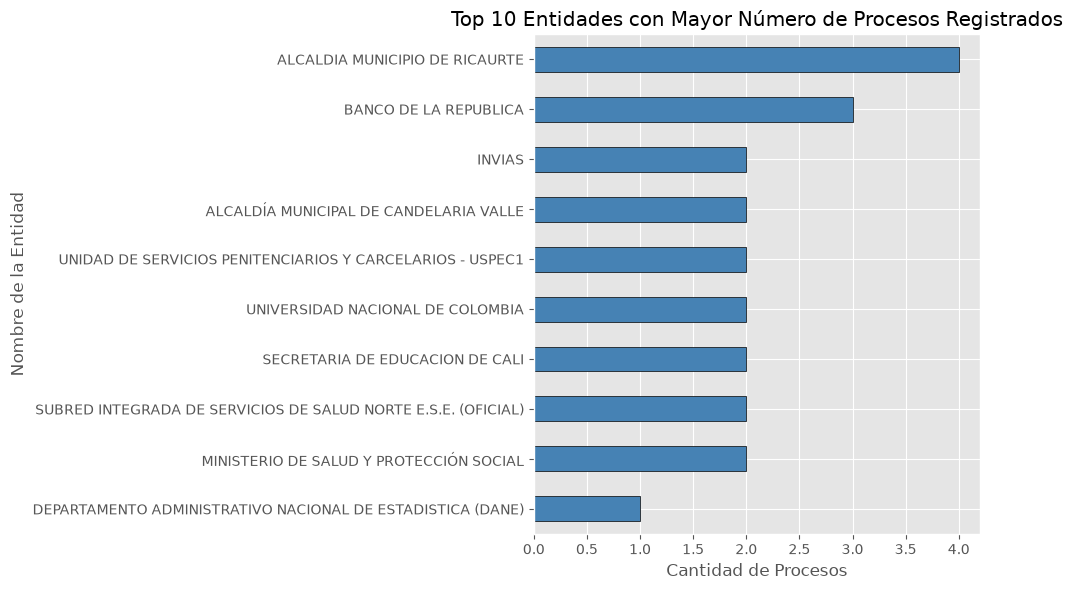

In [7]:
# Vamos a ver gráficamente cuáles son las 10 entidades que más aparecen en este lote de datos
plt.figure(figsize=(10, 6))
top_entidades = df['entidad'].value_counts().head(10)

top_entidades.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Entidades con Mayor Número de Procesos Registrados')
plt.xlabel('Cantidad de Procesos')
plt.ylabel('Nombre de la Entidad')
plt.gca().invert_yaxis() # Para que la entidad con más procesos quede arriba
plt.tight_layout()
plt.show()